# Fixed-Point Quantization Testbed

This notebook evaluates model performance under different fixed-point quantization bit-widths.

**Key Metrics:**
- ROC curves
- AUC (Area Under Curve)
- TPR at FPR = 1e-5

**Quantization formats tested:**
- Float32 (baseline)
- Various fixed-point: Q<I>.<F> where I=integer bits, F=fractional bits

In [1]:
# Imports
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# Set up paths
sys.path.insert(0, os.path.abspath('..'))

from cascaded_tn.quantization import QuantizationTestbed
from cascaded_tn.training.cascaded_model import CascadedModel, create_trainable_autoencoder
from tn4ml.embeddings import embed, TrigonometricEmbedding, ParticleVectorEmbedding
from tn4ml.eval import get_roc_curve_data
from tn4ml.metrics import TransformedNorm

import quimb.tensor as qtn

# Configure JAX
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'float32')

print("✅ Imports successful")

✅ Imports successful


## 1. Load or Create Model

In [2]:
# Load trained model
model_dir = '../output/Huber_AE_Results_bd8_3/'
model_name = 'final_best_model.pkl'
model_path = model_dir + '/' + model_name
autoencoder = CascadedModel.load(model_path)
print(f"✅ Loaded trained model from {model_path}")
print(f"   Parameters: {autoencoder.nparams():,}")

print(f"✅ Model ready")
print(f"   Architecture: {[op.config.input_dim for op in autoencoder.cascade.operators]} → {autoencoder.cascade.operators[-1].config.output_dim}")
print(f"   Parameters: {autoencoder.nparams():,}")
autoencoder.summary()

[LOADING] Model from ../output/Huber_AE_Results_bd8_3//final_best_model.pkl
  - 4,482 parameters
  - 2 layers
[LOADED] Successfully loaded model
✅ Loaded trained model from ../output/Huber_AE_Results_bd8_3//final_best_model.pkl
   Parameters: 4,482
✅ Model ready
   Architecture: [19, 7] → 3
   Parameters: 4,482

CASCADED MODEL SUMMARY

CASCADE SUMMARY: OpenAutoencoder_19to3
Architecture: 19 → 7 → 3

Layers: 2
  0: Unified↓(19→7, χ=8)
  1: Unified↓(7→3, χ=3) (bottleneck)


Training Configuration:
  Strategy: global
  Optimizer: <function adam at 0x7fe00018e160>
  Learning rate: 0.01
  Loss function: None
  Training type: 0

Total parameters: 4,482

Parameters by layer:
  Layer 0 (Unified↓(19→7, χ=8)): 4,320 parameters
  Layer 1 (Unified↓(7→3, χ=3)): 162 parameters



## 2. Set Up Embedding and Metric Function

In [3]:
# Set up embedding (use the same one from training)
embedding = ParticleVectorEmbedding(normalize=False)

# Define target loss (adjust based on your training)
target_loss = 50.0

# Define the anomaly score function)
def InputsToNorm(model, data):
    """Norm itself"""
    x = TransformedNorm(model, data)
    return x


# Define the anomaly score function)
def InputsToScore(model, data):
    """Anomaly score based on deviation from target norm."""
    x = TransformedNorm(model, data)
    return jax.lax.abs(x - target_loss)

@jax.jit
def ComputeNorm(data, targets, *params):
    """Compute the norm."""
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    tn_i = embed(data, embedding)
    compressed = temp_model.cascade.apply(tn_i)
    
    return InputsToNorm(compressed, tn_i)


@jax.jit
def ComputeScore(data, targets, *params):
    """Compute the anomaly score."""
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    tn_i = embed(data, embedding)
    compressed = temp_model.cascade.apply(tn_i)
    
    return InputsToScore(compressed, tn_i)

# Vectorize for batch processing
norm_term = jax.jit(jax.vmap(ComputeNorm, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')
score_term = jax.jit(jax.vmap(ComputeScore, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

print("✅ Metric function ready")

✅ Metric function ready


## 3. Create Data Loaders

In [4]:
# Schedule data loading
import utils.dataloader as d
inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/"
background_loader = d.load_data(inputPath + "background_for_training.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True)
signal_loaders = {
    'A to 4l': d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'LQ': d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'H to tau nu': d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
    'H to tau tau': d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True),
}

## 4. Initialize Testbed

In [5]:
# Create testbed
testbed = QuantizationTestbed(model=autoencoder, embedding=embedding)
print("✅ Testbed initialized")

✅ Testbed initialized


## 5. Define Quantization Configurations to Test

In [6]:
# Define quantization configurations to test
# Format: (n_word, n_frac) where n_word = total bits, n_frac = fractional bits
# Integer bits = n_word - n_frac - 1 (for signed)

quantization_configs = [
    # (total_bits, frac_bits, name)
    (18, 12, 'Q5.12 (18-bit)'),   # 1 sign + 5 int + 12 frac
    (17, 11, 'Q5.11 (17-bit)'),   # 1 sign + 5 int + 11 frac
    (16, 11, 'Q4.11 (16-bit)'),   # 1 sign + 4 int + 11 frac
    (15, 9,  'Q5.9 (15-bit)'),    # 1 sign + 5 int + 9 frac
    (14, 9,  'Q4.9 (14-bit)'),    # 1 sign + 4 int + 9 frac
    (13, 8,  'Q4.8 (13-bit)'),    # 1 sign + 4 int + 8 frac
]

print("Quantization configurations to test:")
for n_word, n_frac, name in quantization_configs:
    n_int = n_word - n_frac - 1
    range_val = 2**n_int
    resolution = 2**(-n_frac)
    print(f"  {name}: range=[-{range_val}, {range_val}), resolution={resolution:.8f}")

Quantization configurations to test:
  Q5.12 (18-bit): range=[-32, 32), resolution=0.00024414
  Q5.11 (17-bit): range=[-32, 32), resolution=0.00048828
  Q4.11 (16-bit): range=[-16, 16), resolution=0.00048828
  Q5.9 (15-bit): range=[-32, 32), resolution=0.00195312
  Q4.9 (14-bit): range=[-16, 16), resolution=0.00195312
  Q4.8 (13-bit): range=[-16, 16), resolution=0.00390625


## 6. Evaluate Float32 Baseline

In [7]:
print("\n" + "="*80)
print("EVALUATING FLOAT32 BASELINE")
print("="*80)

# Evaluate background
bkg_float = testbed.evaluate_float(background_loader, norm_term, verbose=True)

# Evaluate signals
signals_float = {}
for signal_name, signal_loader in signal_loaders.items():
    signals_float[signal_name] = testbed.evaluate_float(signal_loader, norm_term, verbose=True)

print("\n✅ Float32 baseline complete")
print(f"   Background: {len(bkg_float)} samples")
print(f"   Signals: {[f'{k} ({len(v)} samples)' for k, v in signals_float.items()]}")


EVALUATING FLOAT32 BASELINE


Evaluating (float32):   0%|          | 0/400 [00:00<?, ?it/s]

Evaluating (float32): 100%|██████████| 70/70 [00:07<00:00,  9.37it/s]


✅ Float32 baseline complete
   Background: 4000000 samples
   Signals: ['A to 4l (55969 samples)', 'LQ (340544 samples)', 'H to tau nu (760272 samples)', 'H to tau tau (691283 samples)']


## 7. Run Quantization Sweep

In [8]:
# Store results
all_norms = {
    'float32': {
        'background': bkg_float,
        'signals': signals_float,
    }
}

# Test each quantization config
for n_word, n_frac, name in quantization_configs:
    print("\n" + "="*80)
    print(f"TESTING: {name}")
    print("="*80)
    
    # Quantize model
    testbed.quantize(n_word=n_word, n_frac=n_frac, signed=True)
    
    # Evaluate background
    bkg_quant = testbed.evaluate_quantized(background_loader, norm_term, verbose=True)
    
    # Evaluate signals
    signals_quant = {}
    for signal_name, signal_loader in signal_loaders.items():
        signals_quant[signal_name] = testbed.evaluate_quantized(signal_loader, norm_term, verbose=True)
    
    # Store results
    all_norms[name] = {
        'background': bkg_quant,
        'signals': signals_quant,
        'config': testbed.config,
        'stats': testbed.stats,
    }
    
    print(f"\n✅ {name} complete")

print("\n" + "="*80)
print("ALL EVALUATIONS COMPLETE")
print("="*80)


TESTING: Q5.12 (18-bit)

[QUANTIZATION] Quantizing model to 18 bits (5 integer, 12 fractional)
  Config: Q5.12

QUANTIZATION STATISTICS: Q5.12
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-32.000000, 31.999756]
Resolution: 0.00024414

Per-tensor statistics:


Evaluating (Q5.12):   0%|          | 0/400 [00:00<?, ?it/s]

Evaluating (Q5.12): 100%|██████████| 70/70 [00:25<00:00,  2.76it/s]



✅ Q5.12 (18-bit) complete

TESTING: Q5.11 (17-bit)

[QUANTIZATION] Quantizing model to 17 bits (5 integer, 11 fractional)
  Config: Q5.11

QUANTIZATION STATISTICS: Q5.11
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-32.000000, 31.999512]
Resolution: 0.00048828

Per-tensor statistics:


Evaluating (Q5.11): 100%|██████████| 70/70 [00:25<00:00,  2.75it/s]


...


✅ Q5.9 (15-bit) complete

TESTING: Q4.9 (14-bit)

[QUANTIZATION] Quantizing model to 14 bits (4 integer, 9 fractional)
  Config: Q4.9

QUANTIZATION STATISTICS: Q4.9
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-16.000000, 15.998047]
Resolution: 0.00195312

Per-tensor statistics:


Evaluating (Q4.9): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]



✅ Q4.9 (14-bit) complete

TESTING: Q4.8 (13-bit)

[QUANTIZATION] Quantizing model to 13 bits (4 integer, 8 fractional)
  Config: Q4.8

QUANTIZATION STATISTICS: Q4.8
Total parameters: 4,482
Clipped parameters: 0 (0.00%)
Weight range: [-7.121814, 6.723738]
Quantization range: [-16.000000, 15.996094]
Resolution: 0.00390625

Per-tensor statistics:


Evaluating (Q4.8): 100%|██████████| 70/70 [00:25<00:00,  2.78it/s]


✅ Q4.8 (13-bit) complete

ALL EVALUATIONS COMPLETE


In [9]:
# ============================================================================
# MIXED PRECISION EVALUATION
# ============================================================================

print("\n" + "="*80)
print("TESTING MIXED PRECISION CONFIGURATIONS")
print("="*80)

# Define mixed-precision configurations to test
# Format: [(layer0_bits, layer0_frac), (layer1_bits, layer1_frac), ...]
mixed_configs = [
    # Name: (Layer0, Layer1, Layer2, ...)
    ("14→16", [(14, 9), (16, 10)]),
    ("15→16", [(15, 9), (16, 10)]),
    ("16→17", [(16, 10), (17, 11)]),
    ("13→16", [(13, 8), (16, 10)]),
]

mixed_results = {}

for config_name, layer_configs in mixed_configs:
    print("\n" + "="*80)
    print(f"TESTING MIXED: {config_name}")
    print("="*80)
    
    # Quantize with mixed precision
    testbed.quantize_mixed(layer_configs=layer_configs, signed=True)
    
    # Evaluate background
    bkg_mixed = testbed.evaluate_mixed(background_loader, norm_term, verbose=True)
    
    # Evaluate signals
    signals_mixed = {}
    for signal_name, signal_loader in signal_loaders.items():
        signals_mixed[signal_name] = testbed.evaluate_mixed(signal_loader, norm_term, verbose=True)
    
    # Store results
    mixed_results[config_name] = {
        'background': bkg_mixed,
        'signals': signals_mixed,
        'configs': testbed.mixed_configs,
        'stats': testbed.mixed_stats,
    }
    
    print(f"✅ {config_name} complete")

print("\n" + "="*80)
print("MIXED PRECISION EVALUATIONS COMPLETE")
print("="*80)


TESTING MIXED PRECISION CONFIGURATIONS

TESTING MIXED: 14→16

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q4.9 - 4320 params, 0 clipped
  Layer 1: Q5.10 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q4.9 → Q5.10):   0%|          | 0/400 [00:00<?, ?it/s]

Evaluating (mixed: Q4.9 → Q5.10): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]


✅ 14→16 complete

TESTING MIXED: 15→16

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q5.9 - 4320 params, 0 clipped
  Layer 1: Q5.10 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q5.9 → Q5.10): 100%|██████████| 70/70 [00:25<00:00,  2.76it/s]


✅ 15→16 complete

TESTING MIXED: 16→17

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q5.10 - 4320 params, 0 clipped
  Layer 1: Q5.11 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q5.10 → Q5.11): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]


✅ 16→17 complete

TESTING MIXED: 13→16

[MIXED QUANTIZATION] Quantizing 2 layers with different precisions
  Layer 0: Q4.8 - 4320 params, 0 clipped
  Layer 1: Q5.10 - 162 params, 0 clipped
✅ Mixed quantization complete


Evaluating (mixed: Q4.8 → Q5.10): 100%|██████████| 70/70 [00:25<00:00,  2.77it/s]

✅ 13→16 complete

MIXED PRECISION EVALUATIONS COMPLETE


In [10]:
output_dir = model_dir+'/quantization_results'
os.makedirs(output_dir, exist_ok=True)

## 8. Plot Norm Distributions

Plot the norms for various quantizations to get a sense of the shifted peak

In [11]:
# Also print medians to help set targets
print("\nMedian background norms for mixed precision:")
for config_name, results in all_norms.items():
    median_val = np.median(results['background'])
    print(f"  {config_name}: {median_val:.2f}")


Median background norms for mixed precision:
  float32: 50.02
  Q5.12 (18-bit): 48.86
  Q5.11 (17-bit): 47.74
  Q4.11 (16-bit): 47.74
  Q5.9 (15-bit): 41.44
  Q4.9 (14-bit): 41.44
  Q4.8 (13-bit): 34.74


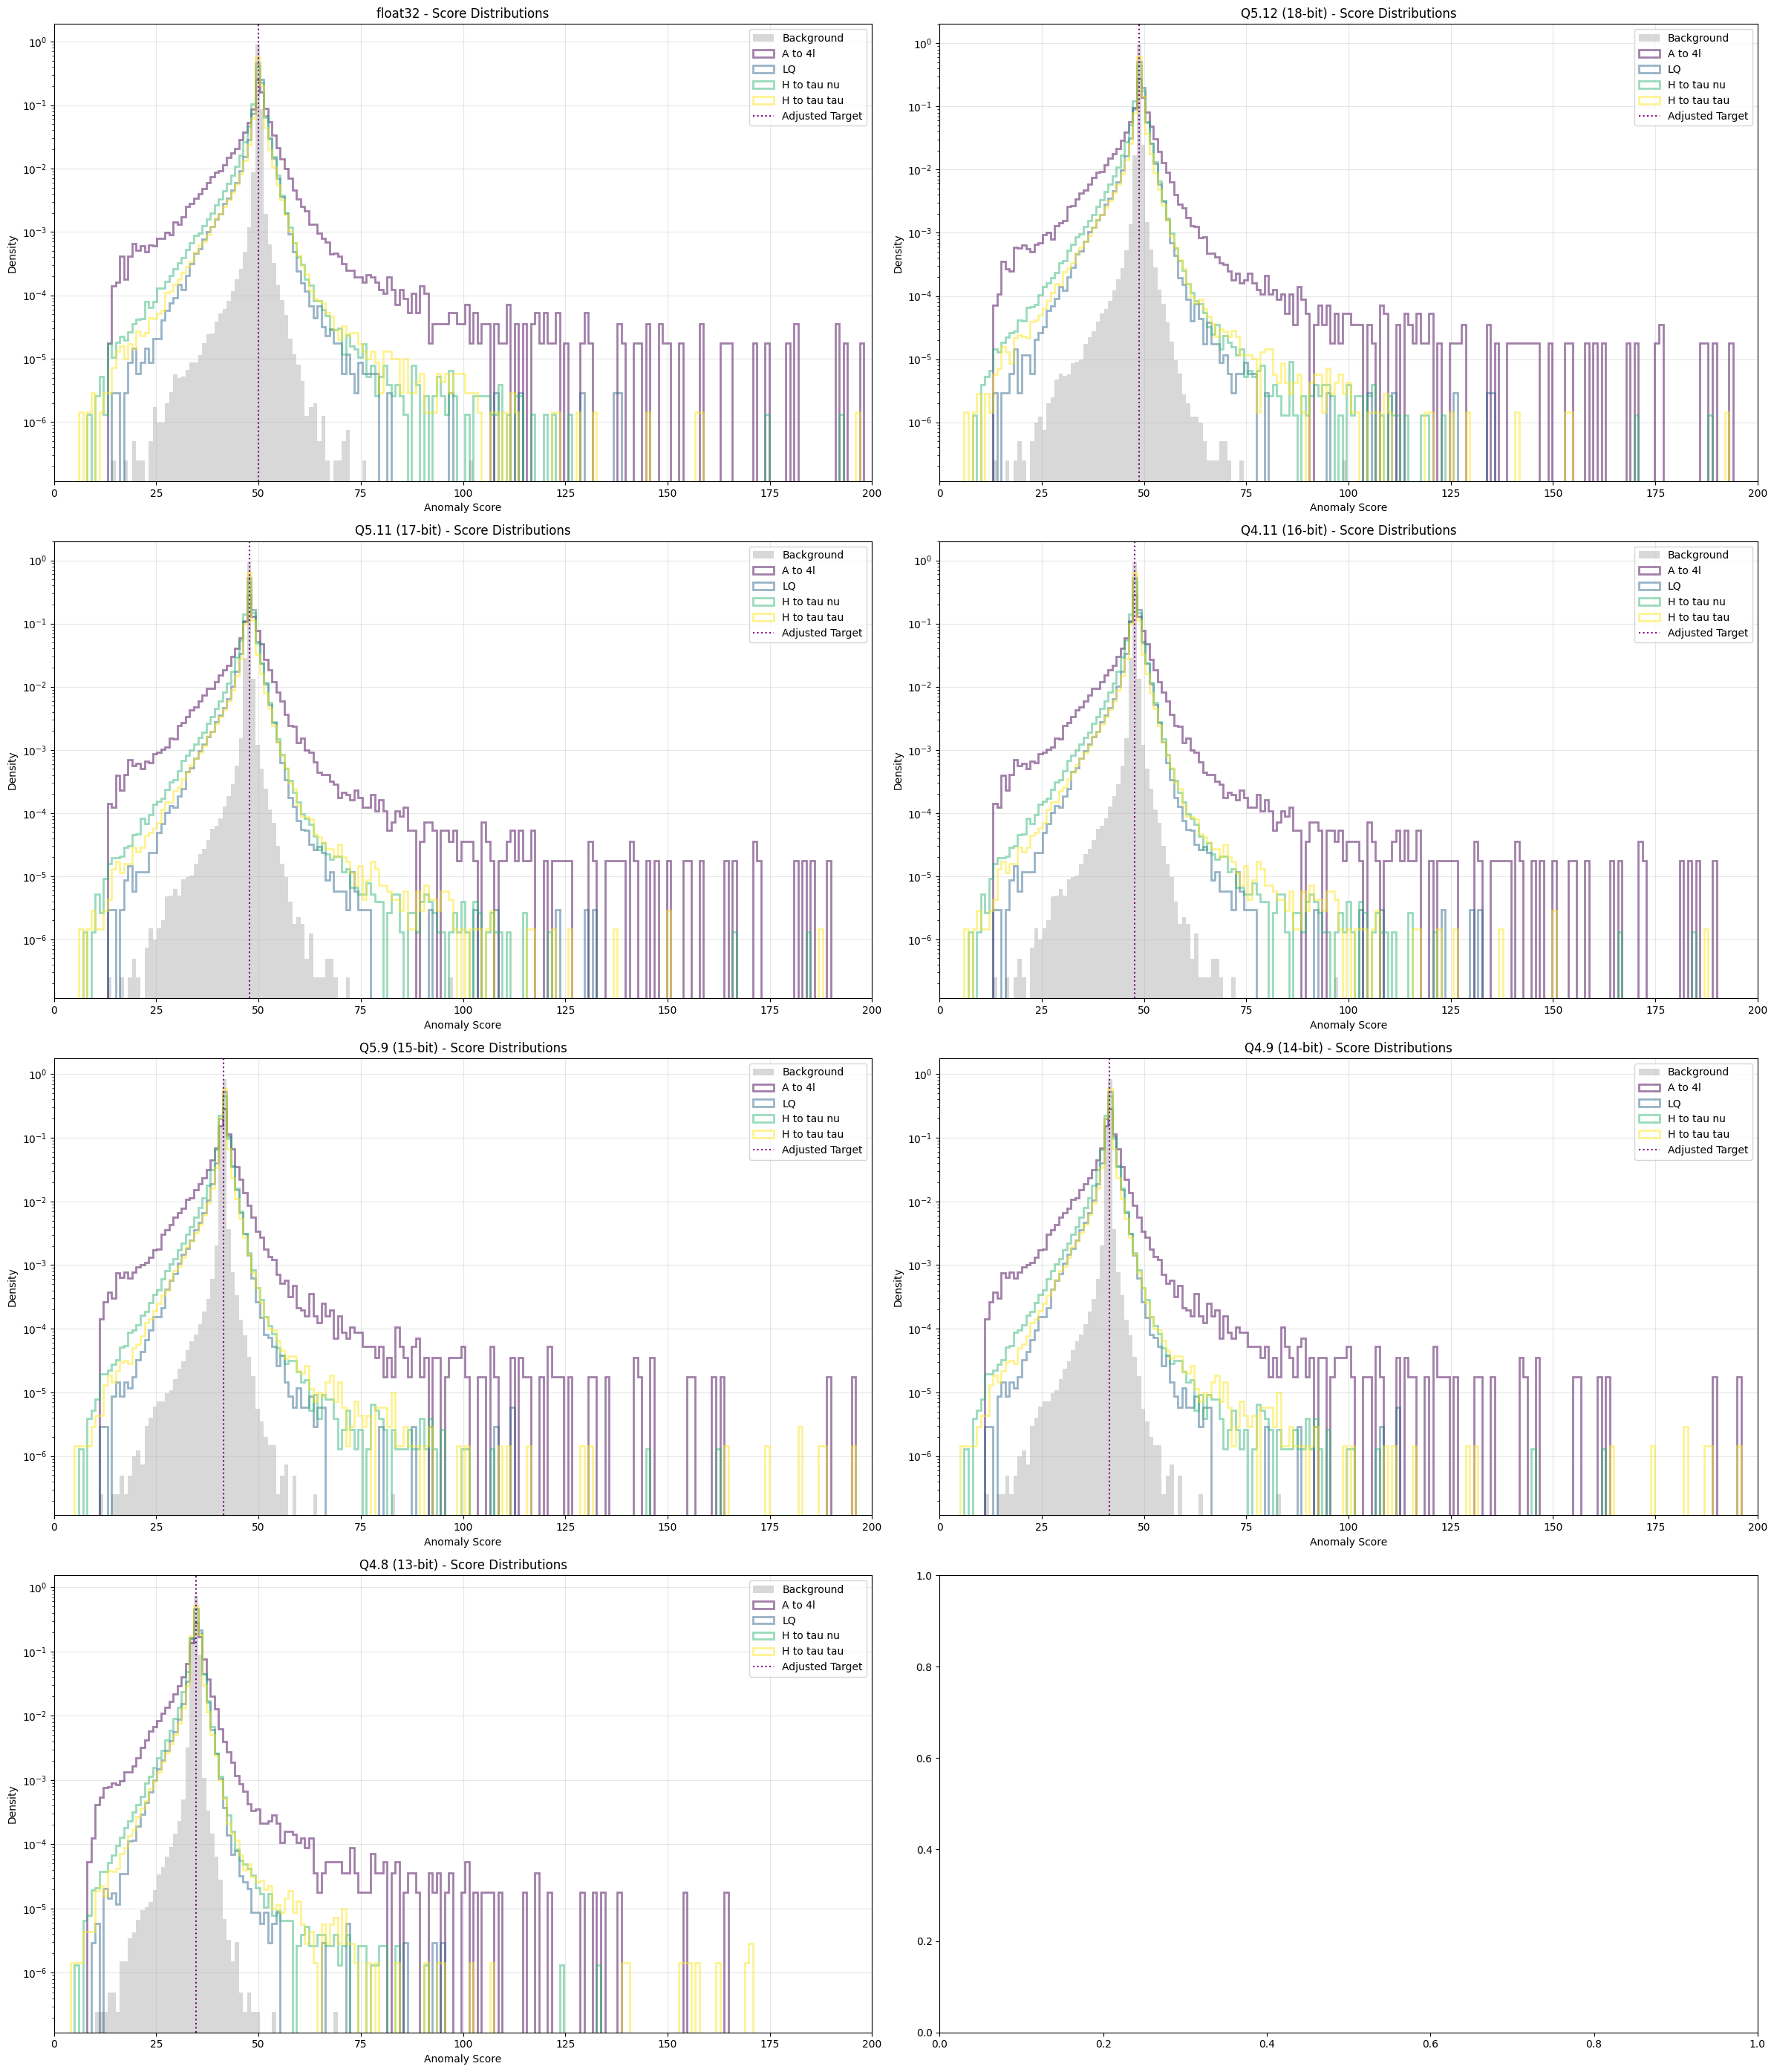

In [36]:
targets_adjusted = {
    'float32': 50.0,
    'Q5.12 (18-bit)': 48.85,
    'Q5.11 (17-bit)': 47.75,
    'Q4.11 (16-bit)': 47.75,
    'Q5.10 (16-bit)': 45.5,
    'Q7.8 (16-bit)': 34.5,
    'Q5.9 (15-bit)': 41.5,
    'Q4.9 (14-bit)': 41.5,
    'Q4.8 (13-bit)': 34.75,
    'Q3.8 (12-bit)': 35.0,
    'Q5.6 (12-bit)': 10.5,
    'Q3.4 (8-bit)': 0.05,
}

# Plot distributions for each precision
n_configs = len(all_norms)
n_signals = len(signal_loaders)

import math
fig, axes = plt.subplots(math.ceil(n_configs/2), 2, figsize=(24, 4*n_configs))
if n_configs == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(all_norms.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals for each config
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])
        
    ax.axvline(targets_adjusted[config_name], color='purple', linestyle=':', label='Adjusted Target')

    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{config_name} - Score Distributions')
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/norm_distributions_byprecision.png")
plt.show()

In [37]:
# Also print medians to help set targets
print("\nMedian background norms for mixed precision:")
for config_name, results in mixed_results.items():
    median_val = np.median(results['background'])
    print(f"  {config_name}: {median_val:.2f}")


Median background norms for mixed precision:
  14→16: 42.60
  15→16: 42.60
  16→17: 46.06
  13→16: 36.84


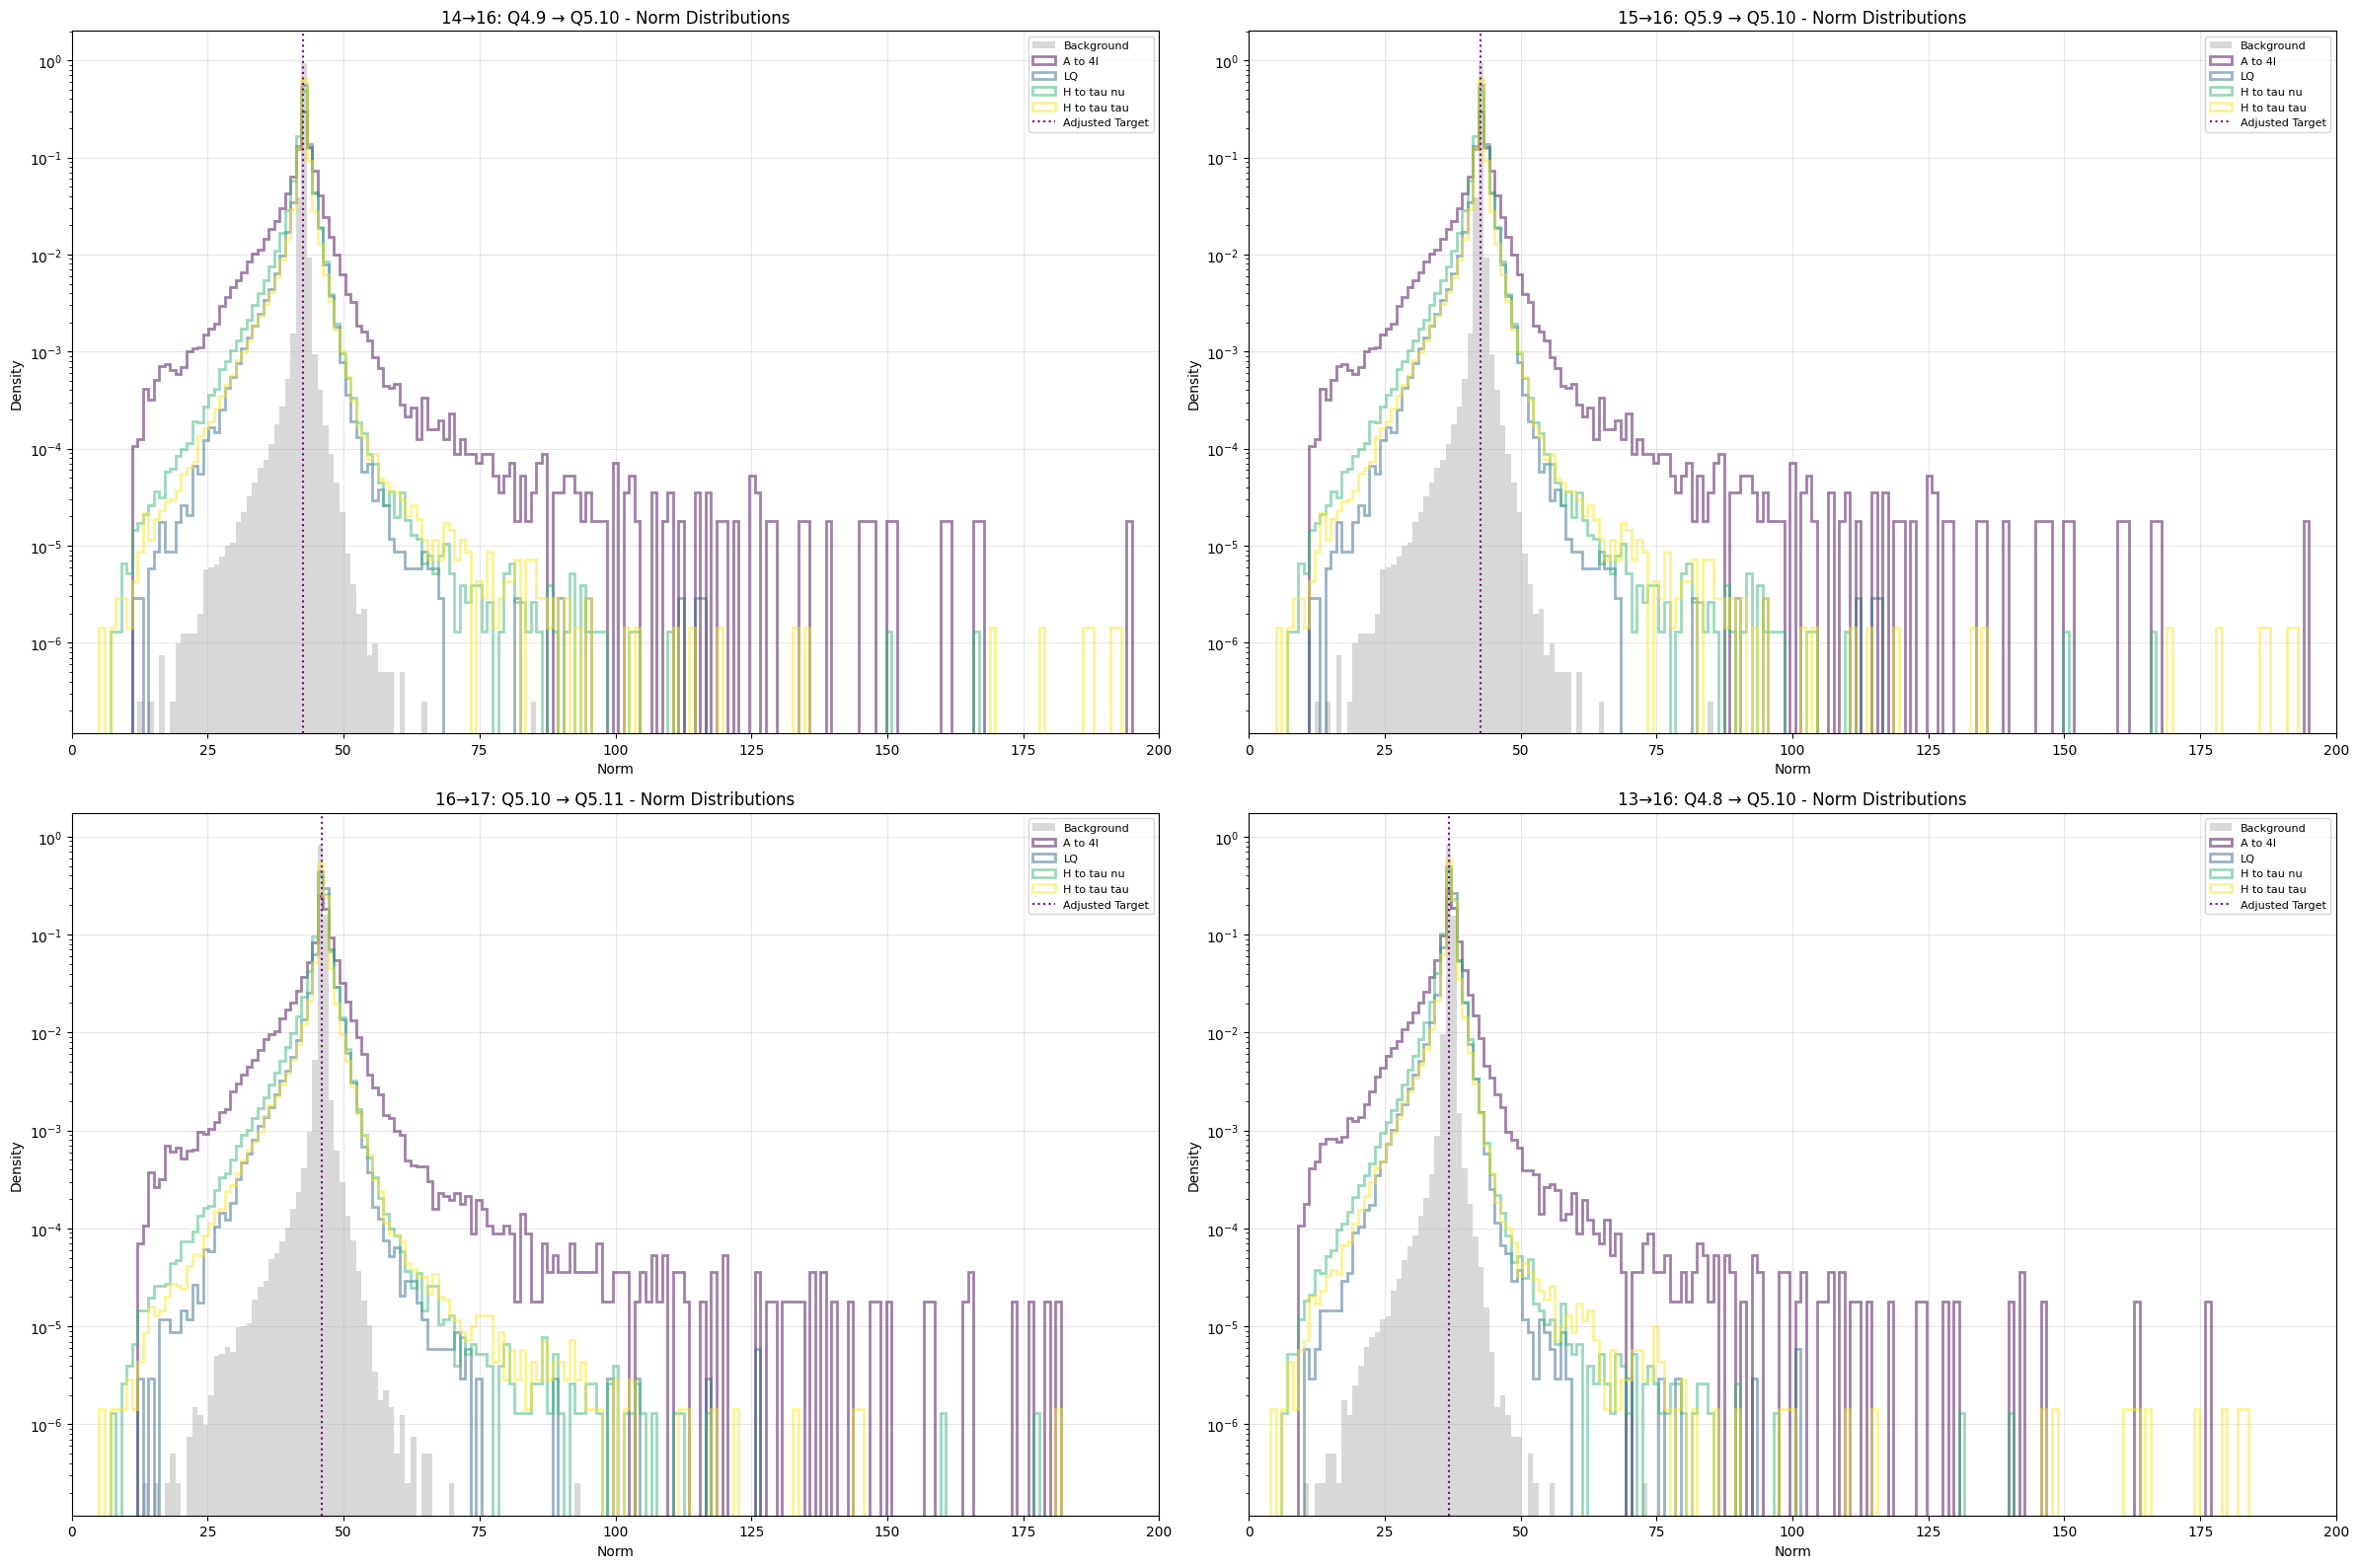

In [38]:
# Define adjusted targets for mixed precision configs
mixed_targets = {
    '18→16': 45.0,
    '18→12': 32.0,
    '16→12': 24.0,
    '16→8':  4.0,
    '15→16': 42.6,
    '14→16': 42.6,
    '16→17': 46.0,
    '13→16': 36.85,
}

# Plot distributions for each mixed precision config
n_mixed_configs = len(mixed_results)
n_signals = len(signal_loaders)

fig, axes = plt.subplots(math.ceil(n_mixed_configs/2), 2, figsize=(24, 4*n_mixed_configs))
if n_mixed_configs == 1:
    axes = [[axes]]
elif n_mixed_configs == 2:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(mixed_results.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_norms = results['background']
    ax.hist(bkg_norms, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_norms = results['signals'][signal_name]
        ax.hist(sig_norms, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])
    
    # Mark adjusted target
    if config_name in mixed_targets:
        ax.axvline(mixed_targets[config_name], color='purple', linestyle=':', label='Adjusted Target')

    ax.set_xlabel('Norm')
    ax.set_ylabel('Density')
    
    # Add layer configs to title
    layer_info = " → ".join([str(c) for c in results['configs']])
    ax.set_title(f'{config_name}: {layer_info} - Norm Distributions')
    ax.legend(loc='best', fontsize=8)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/norm_distributions_mixed_precision.png", dpi=150)
plt.show()

## 9. Extract Targets Per Quantization

Extract new targets, and calculate anomaly scores accordingly

In [39]:
def norms_to_scores(all_norms, targets):
    """
    Convert stored norms to anomaly scores with precision-specific targets.
    
    Args:
        all_norms: Dict with norm values per config
        targets: Dict mapping config_name -> target value
                 e.g., {'float32': 50.0, 'Q5.12 (18-bit)': 51.0, ...}
    
    Returns:
        all_scores: Dict with anomaly scores per config
    """
    all_scores = {}
    
    for config_name, results in all_norms.items():
        # Get target for this config
        target = targets.get(config_name, 50.0)  # Default to 50.0 if not specified
        
        all_scores[config_name] = {
            'background': np.abs(results['background'] - target),
            'signals': {
                sig_name: np.abs(sig_norms - target)
                for sig_name, sig_norms in results['signals'].items()
            }
        }
        
        # Copy config/stats if present
        if 'config' in results:
            all_scores[config_name]['config'] = results['config']
        if 'stats' in results:
            all_scores[config_name]['stats'] = results['stats']
    
    return all_scores

# targets_adjusted = {config: 50.0 for config in all_norms.keys()}

all_scores = norms_to_scores(all_norms, targets_adjusted)
mixed_scores = norms_to_scores(mixed_results, mixed_targets)

## 10. Compute Performance Metrics

Calculate AUC and TPR @ FPR=1e-5 for each configuration.

In [40]:
def get_tpr_at_fpr(fpr_array, tpr_array, target_fpr=1e-5):
    """Get TPR at specific FPR value."""
    idx = np.searchsorted(fpr_array, target_fpr, side='right')
    if idx >= len(tpr_array):
        idx = -1
    return tpr_array[idx]

# Compute metrics for all configs and signals
metrics_table = []

for config_name, results in all_scores.items():
    bkg = results['background']
    
    for signal_name, sig in results['signals'].items():
        # Compute ROC
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        tpr_at_1e5 = get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5)
        
        metrics_table.append({
            'Config': config_name,
            'Signal': signal_name,
            'AUC': auc_val,
            'TPR@FPR=1e-5': tpr_at_1e5,
        })

# Create DataFrame
df_metrics = pd.DataFrame(metrics_table)

# Pivot for easier comparison
df_auc = df_metrics.pivot(index='Signal', columns='Config', values='AUC')
df_tpr = df_metrics.pivot(index='Signal', columns='Config', values='TPR@FPR=1e-5')

print("\n" + "="*80)
print("AUC COMPARISON")
print("="*80)
print(df_auc.to_string())

print("\n" + "="*80)
print("TPR @ FPR=1e-5 COMPARISON")
print("="*80)
print(df_tpr.to_string())

# Calculate degradation relative to float32
print("\n" + "="*80)
print("AUC DEGRADATION (vs Float32)")
print("="*80)
df_auc_deg = df_auc.subtract(df_auc['float32'], axis=0)
print(df_auc_deg.to_string())

print("\n" + "="*80)
print("TPR DEGRADATION (vs Float32)")
print("="*80)
df_tpr_deg = df_tpr.subtract(df_tpr['float32'], axis=0)
print(df_tpr_deg.to_string())


AUC COMPARISON
Config        Q4.11 (16-bit)  Q4.8 (13-bit)  Q4.9 (14-bit)  Q5.11 (17-bit)  Q5.12 (18-bit)  Q5.9 (15-bit)   float32
Signal                                                                                                             
A to 4l             0.891007       0.809250       0.877699        0.891007        0.891223       0.877699  0.890695
H to tau nu         0.822883       0.703527       0.797577        0.822883        0.823651       0.797577  0.824161
H to tau tau        0.730790       0.656406       0.708970        0.730790        0.728679       0.708970  0.727152
LQ                  0.790072       0.688533       0.762018        0.790072        0.790559       0.762018  0.790089

TPR @ FPR=1e-5 COMPARISON
Config        Q4.11 (16-bit)  Q4.8 (13-bit)  Q4.9 (14-bit)  Q5.11 (17-bit)  Q5.12 (18-bit)  Q5.9 (15-bit)   float32
Signal                                                                                                             
A to 4l             0.012578 

In [41]:
# Compute metrics for mixed precision (same code!)
mixed_metrics_table = []

for config_name, results in mixed_scores.items():
    bkg = results['background']
    
    for signal_name, sig in results['signals'].items():
        # Compute ROC
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        tpr_at_1e5 = get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5)
        
        mixed_metrics_table.append({
            'Config': config_name,
            'Signal': signal_name,
            'AUC': auc_val,
            'TPR@FPR=1e-5': tpr_at_1e5,
        })

# Create DataFrame
df_mixed_metrics = pd.DataFrame(mixed_metrics_table)
df_mixed_auc = df_mixed_metrics.pivot(index='Signal', columns='Config', values='AUC')
df_mixed_tpr = df_mixed_metrics.pivot(index='Signal', columns='Config', values='TPR@FPR=1e-5')

print("\n" + "="*80)
print("MIXED PRECISION - AUC COMPARISON")
print("="*80)
print(df_mixed_auc.to_string())

print("\n" + "="*80)
print("MIXED PRECISION - TPR @ FPR=1e-5 COMPARISON")
print("="*80)
print(df_mixed_tpr.to_string())

# Compare best mixed vs uniform configs
print("\n" + "="*80)
print("MIXED vs UNIFORM (Side-by-side)")
print("="*80)
# Combine the two dataframes
df_combined_auc = pd.concat([
    df_auc[['float32', 'Q5.12 (18-bit)', 'Q5.9 (15-bit)', 'Q4.9 (14-bit)', 'Q4.8 (13-bit)']],
    df_mixed_auc
], axis=1)
print(df_combined_auc.to_string())


MIXED PRECISION - AUC COMPARISON
Config           13→16     14→16     15→16     16→17
Signal                                              
A to 4l       0.857971  0.885623  0.885623  0.885850
H to tau nu   0.766059  0.815415  0.815415  0.814737
H to tau tau  0.692494  0.720766  0.720766  0.715804
LQ            0.740856  0.781205  0.781205  0.781169

MIXED PRECISION - TPR @ FPR=1e-5 COMPARISON
Config           13→16     14→16     15→16     16→17
Signal                                              
A to 4l       0.012275  0.012400  0.012400  0.012596
H to tau nu   0.001119  0.001161  0.001161  0.001202
H to tau tau  0.000775  0.000797  0.000797  0.000833
LQ            0.000335  0.000335  0.000335  0.000332

MIXED vs UNIFORM (Side-by-side)
Config         float32  Q5.12 (18-bit)  Q5.9 (15-bit)  Q4.9 (14-bit)  Q4.8 (13-bit)     13→16     14→16     15→16     16→17
Signal                                                                                                                     
A to

## 11. Plot Score Distributions

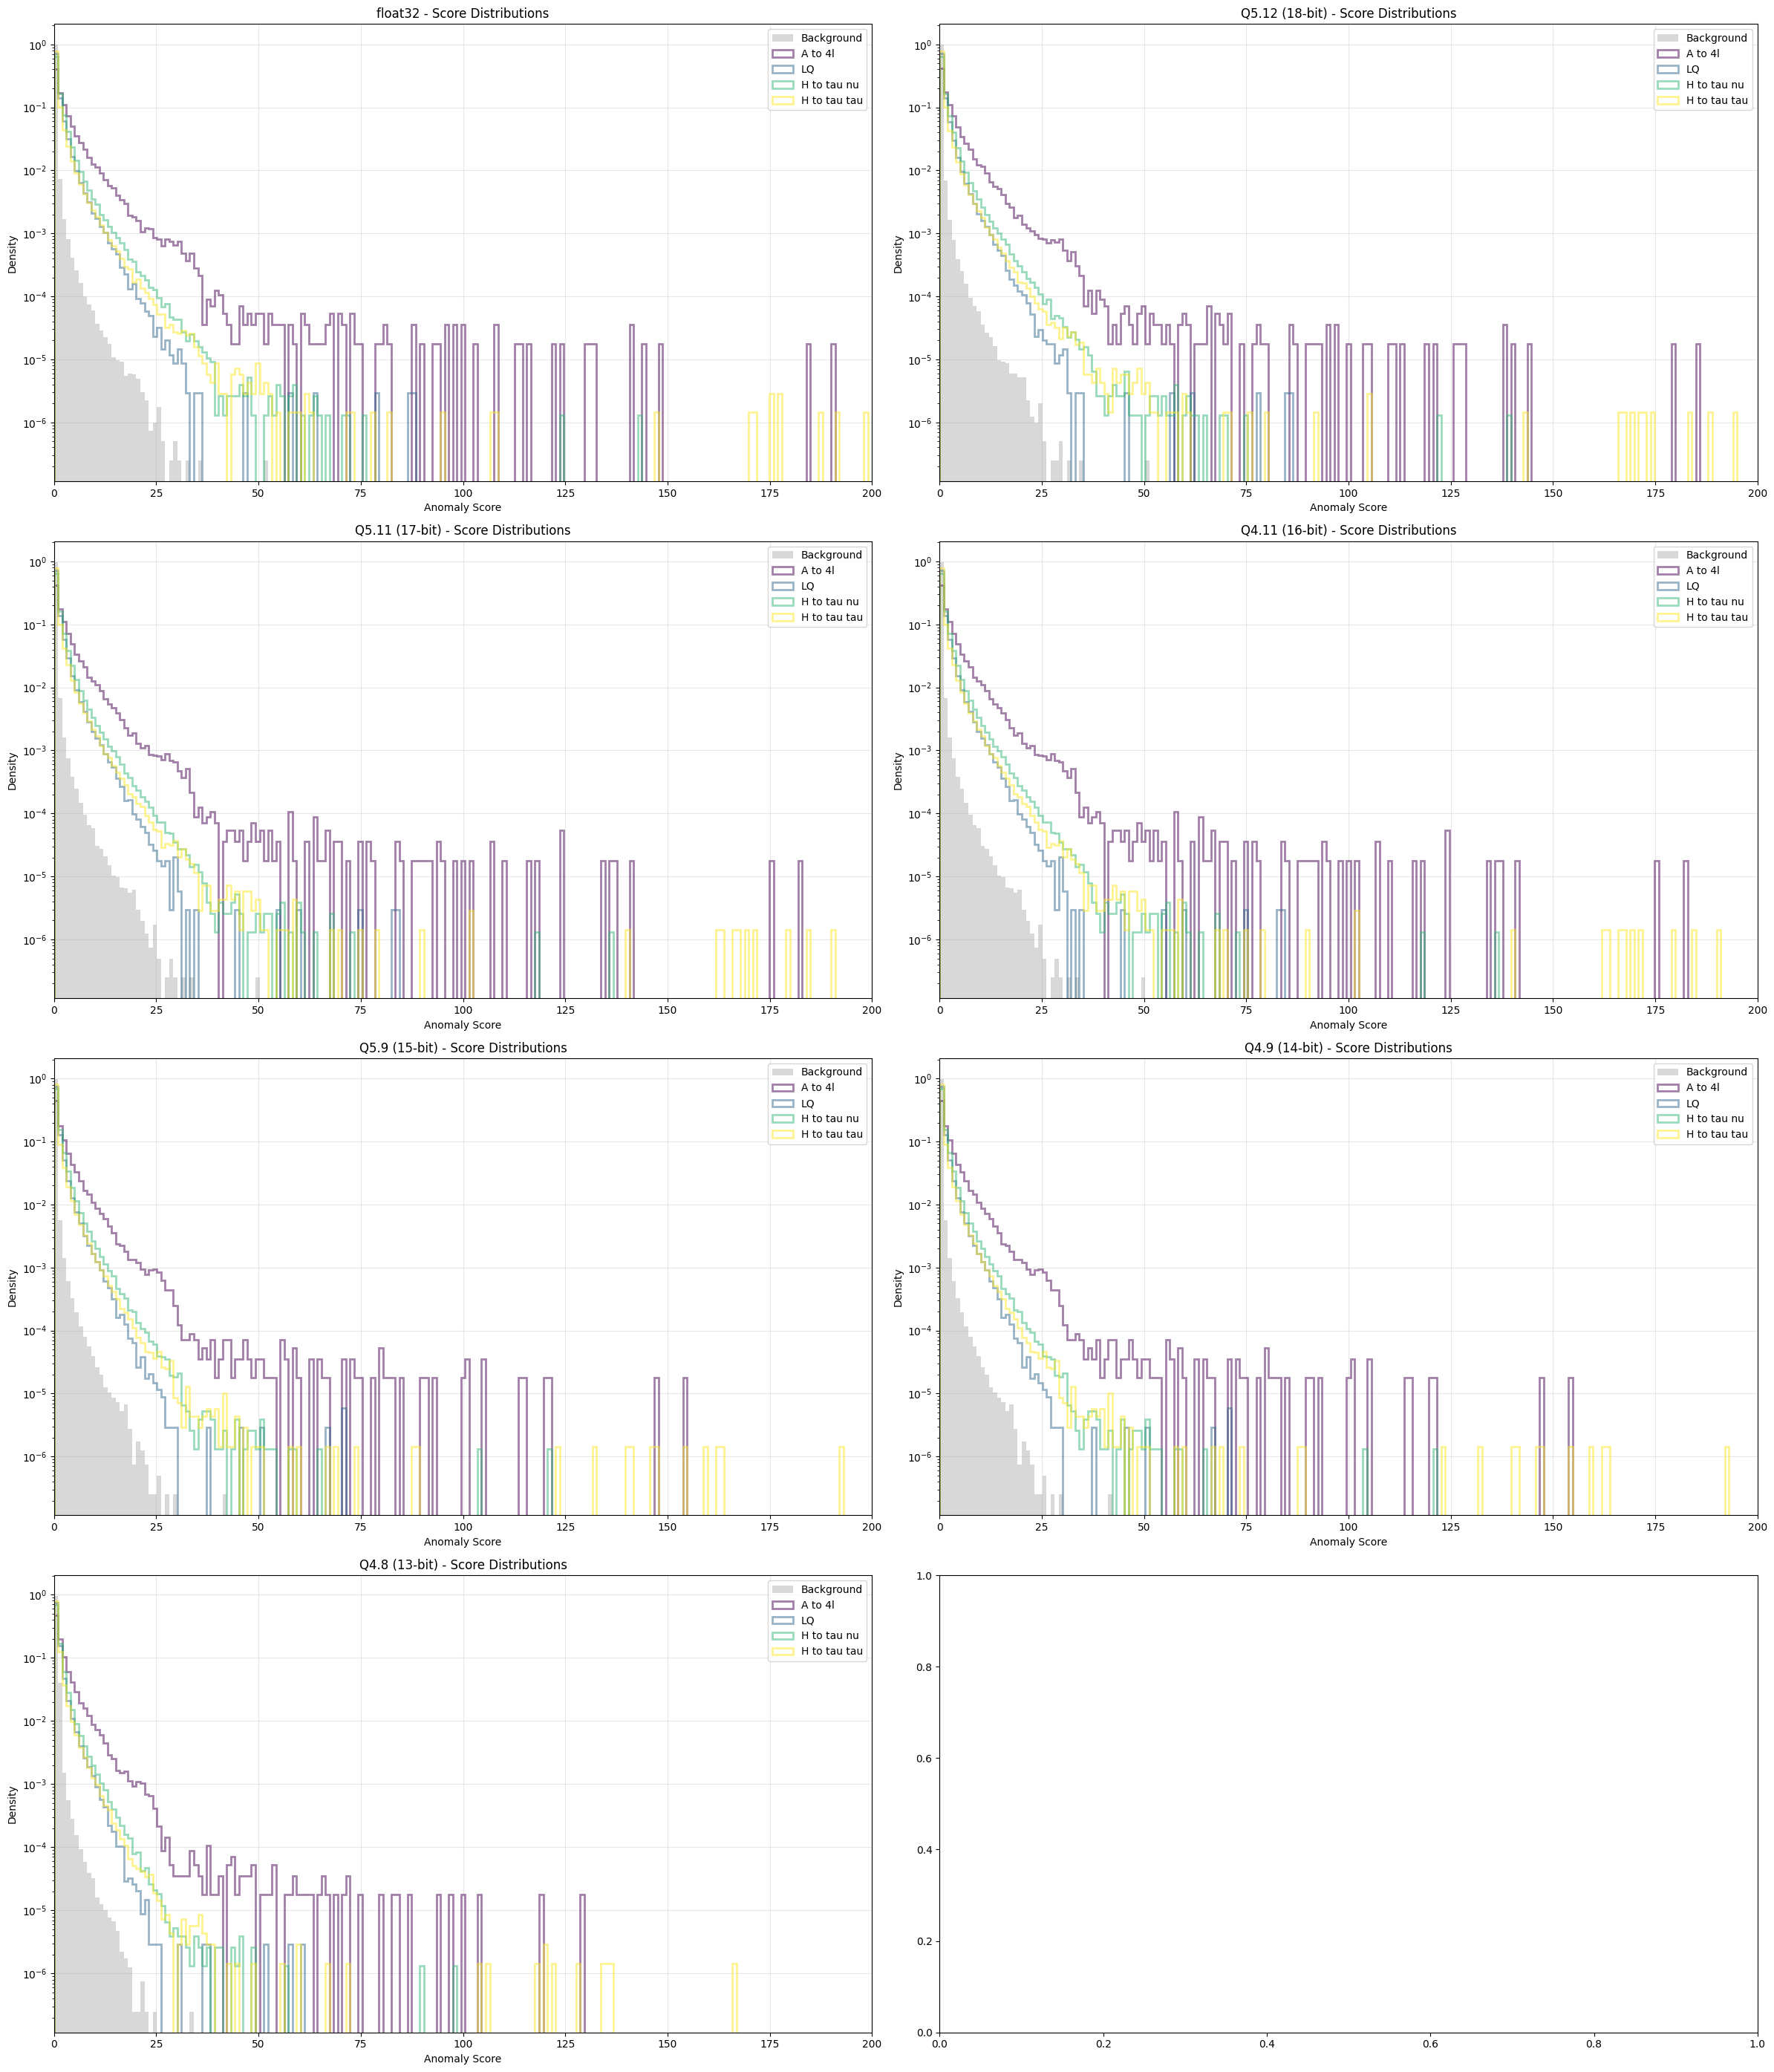

In [42]:
# Plot distributions for each precision
n_configs = len(all_scores)
n_signals = len(signal_loaders)

import math
fig, axes = plt.subplots(math.ceil(n_configs/2), 2, figsize=(24, 4*n_configs))
if n_configs == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(all_scores.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals for each config
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])

    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(f'{config_name} - Score Distributions')
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/anomaly_score_distributions_byprecision.png")
plt.show()

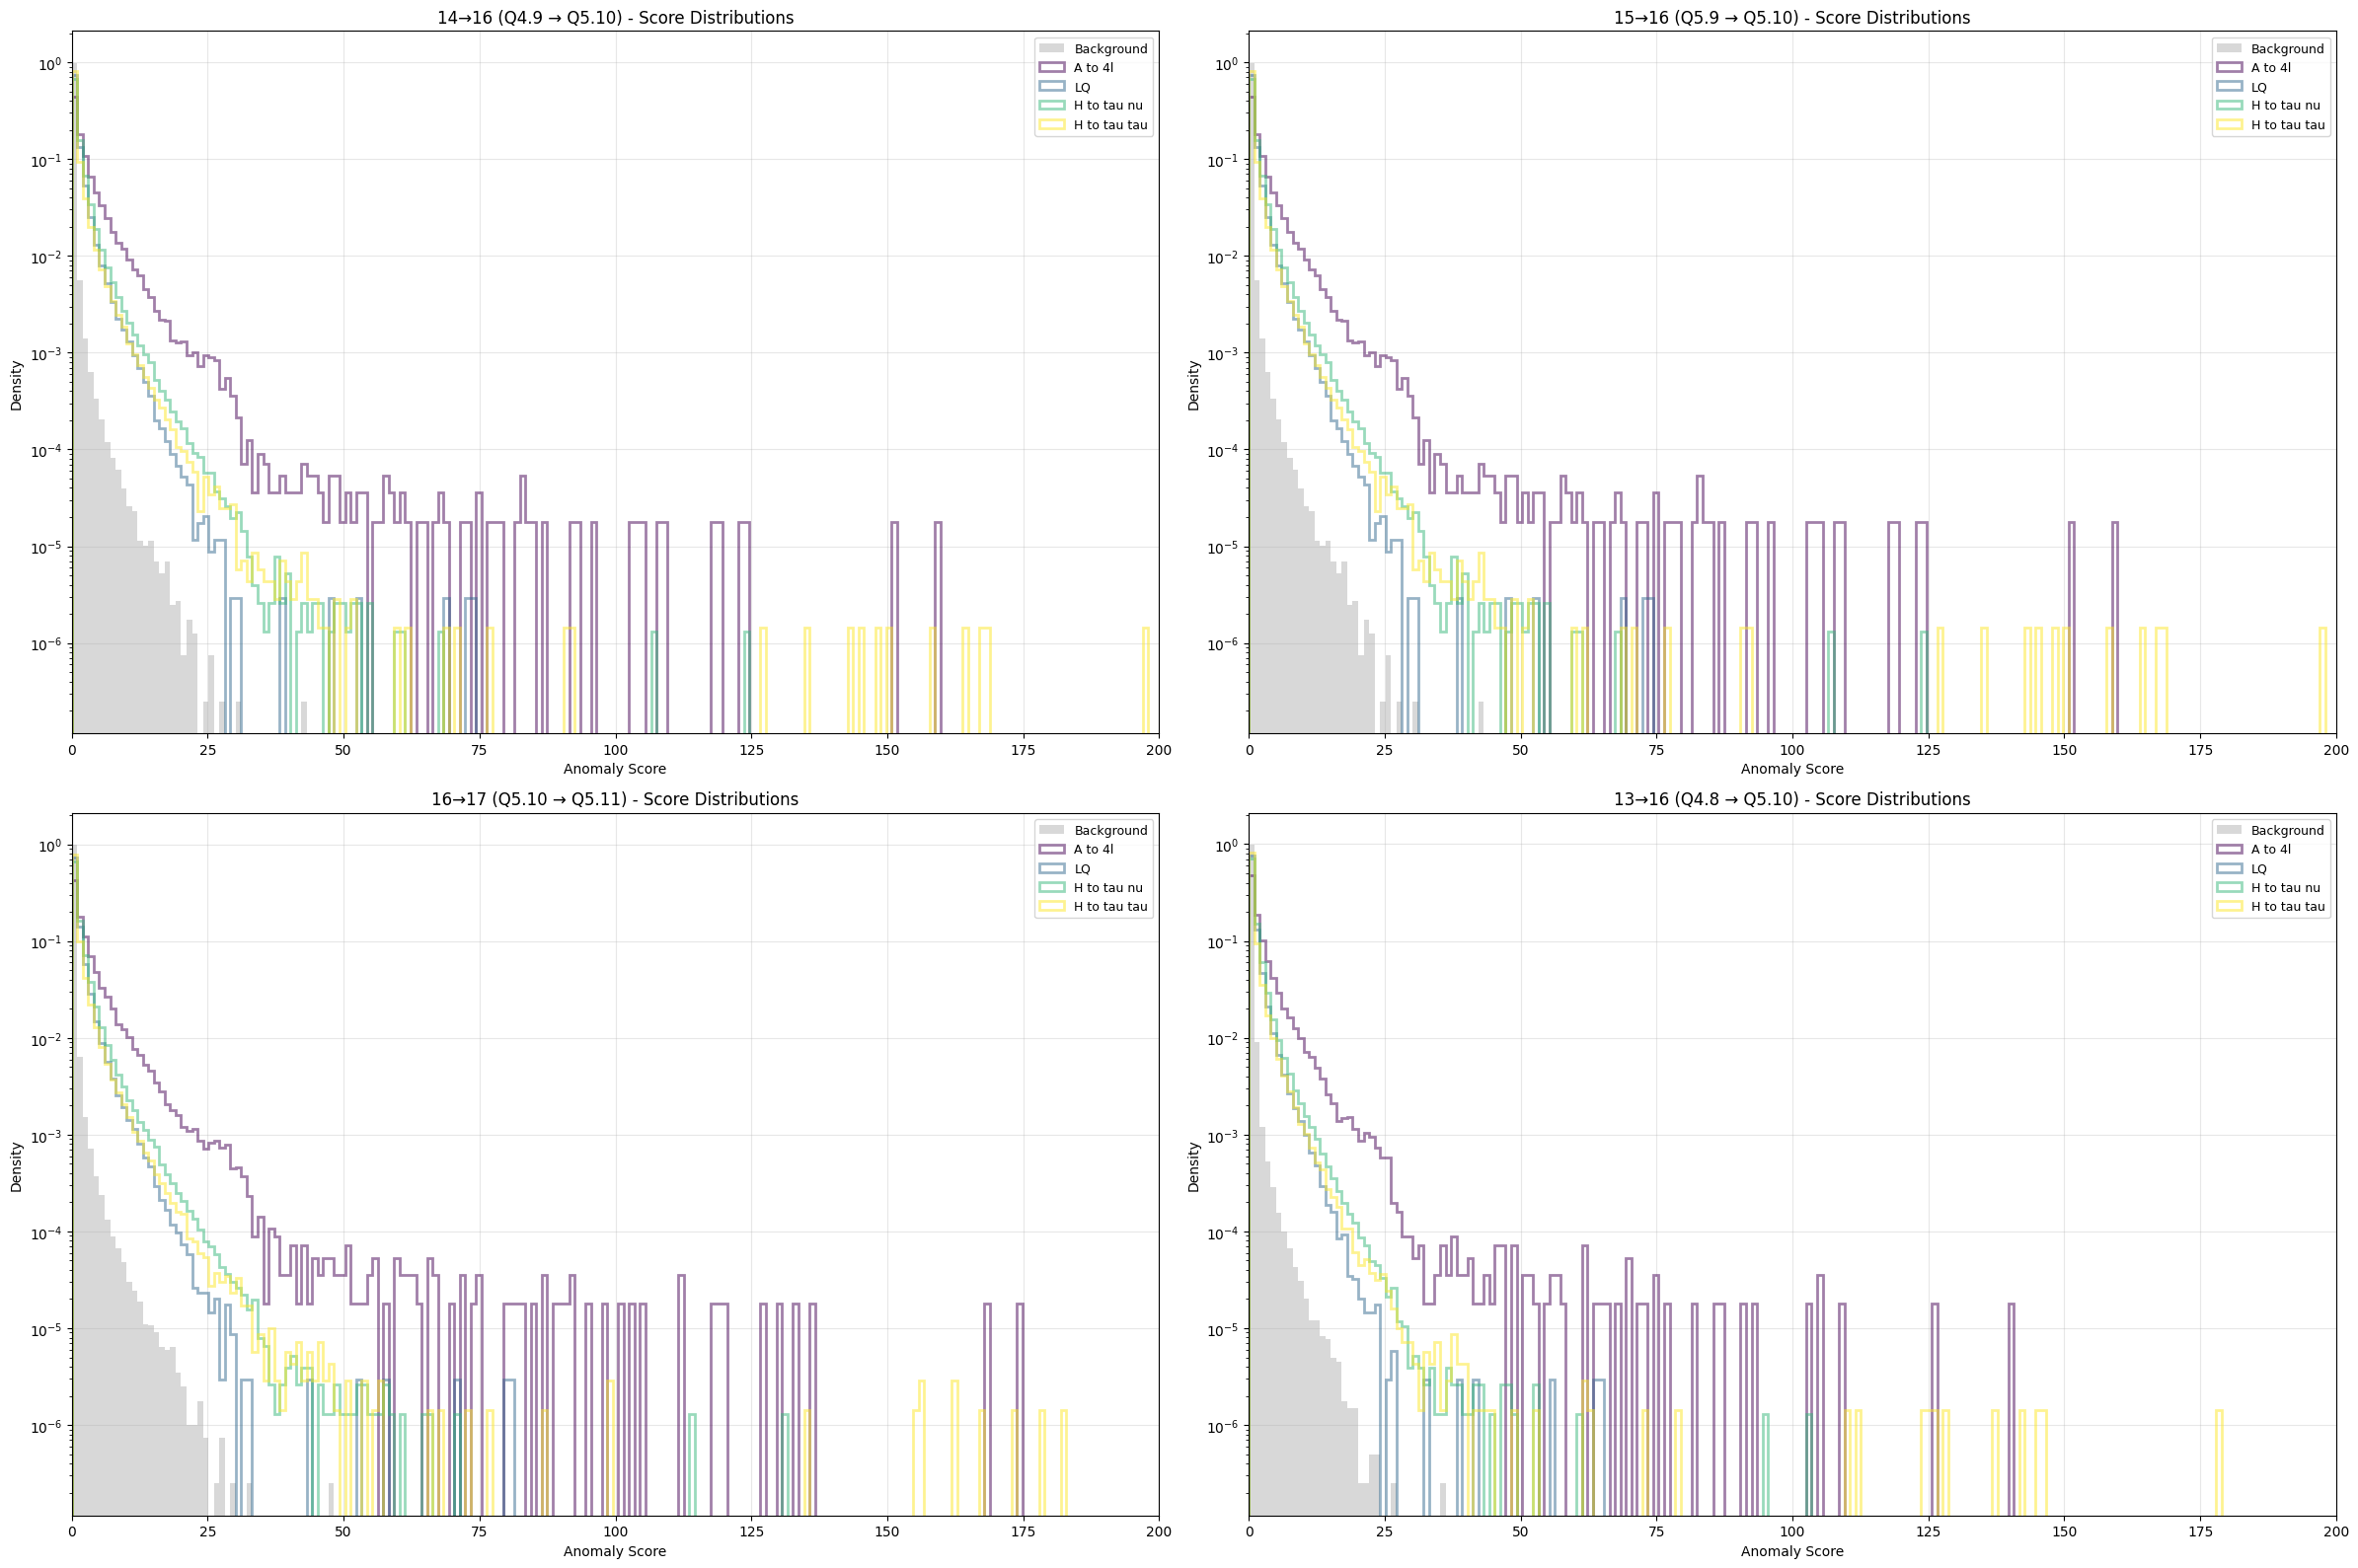

In [43]:
# Plot distributions for each mixed precision config
n_mixed_configs = len(mixed_scores)
n_signals = len(signal_loaders)

fig, axes = plt.subplots(math.ceil(n_mixed_configs/2), 2, figsize=(24, 4*n_mixed_configs))
if n_mixed_configs == 1:
    axes = [[axes]]
elif n_mixed_configs == 2:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, n_signals))
xmin = 0
xmax = 200
bins = np.linspace(xmin, xmax, xmax-xmin)

for config_idx, (config_name, results) in enumerate(mixed_scores.items()):
    ax = axes[int(config_idx/2)][config_idx%2]

    # Plot background
    bkg_scores = results['background']
    ax.hist(bkg_scores, bins=bins, alpha=0.3, label='Background', 
            density=True, histtype='stepfilled', color='gray')
    
    # Plot signals
    for sig_idx, signal_name in enumerate(signal_loaders.keys()):
        sig_scores = results['signals'][signal_name]
        ax.hist(sig_scores, bins=bins, alpha=0.5, label=f'{signal_name}',
                density=True, histtype='step', linewidth=2, color=colors[sig_idx])

    # Add layer configs to title for context
    if config_name in mixed_results and 'configs' in mixed_results[config_name]:
        layer_info = " → ".join([str(c) for c in mixed_results[config_name]['configs']])
        title = f'{config_name} ({layer_info}) - Score Distributions'
    else:
        title = f'{config_name} - Score Distributions'
    
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.set_xlim([xmin, xmax])

plt.tight_layout()
plt.savefig(output_dir+"/anomaly_score_distributions_mixed_precision.png", dpi=150)
plt.show()

## 12. Plot ROC Curves

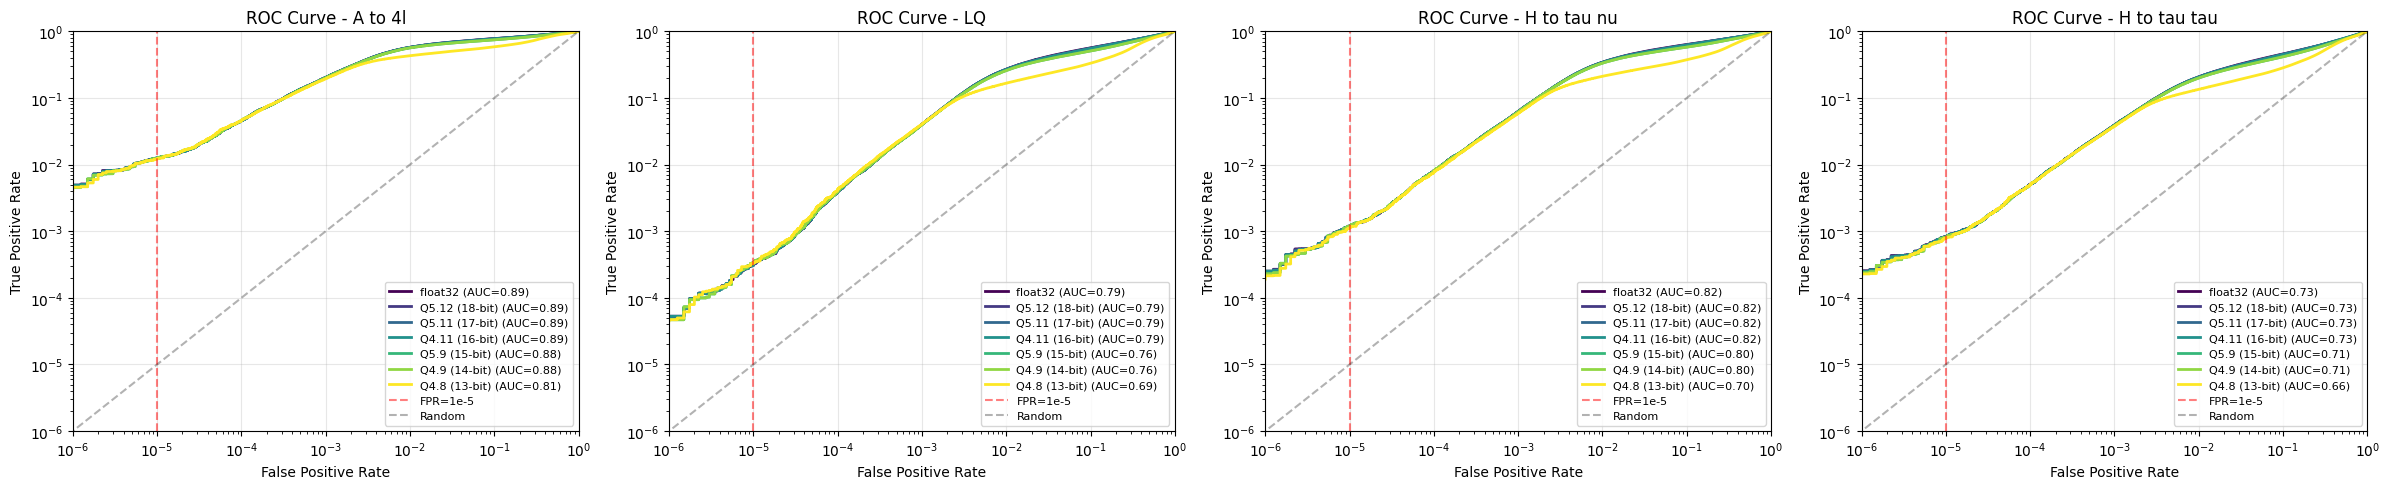

In [48]:
# Plot ROC curves for each signal
colors = plt.cm.viridis(np.linspace(0, 1, len(all_scores)))

fig, axes = plt.subplots(1, n_signals, figsize=(6*n_signals, 5))
if n_signals == 1:
    axes = [axes]

for sig_idx, signal_name in enumerate(signal_loaders.keys()):
    ax = axes[sig_idx]
    
    # Plot ROC for each config
    for config_idx, (config_name, results) in enumerate(all_scores.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, label=f'{config_name} (AUC={auc_val:.2f})',
                linewidth=2, color=colors[config_idx])
    
    # Add FPR = 1e-5 line
    ax.axvline(x=1e-5, color='red', linestyle='--', alpha=0.5, label='FPR=1e-5')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {signal_name}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])

plt.tight_layout()
plt.savefig(output_dir+"/roc_curves.png")
plt.show()

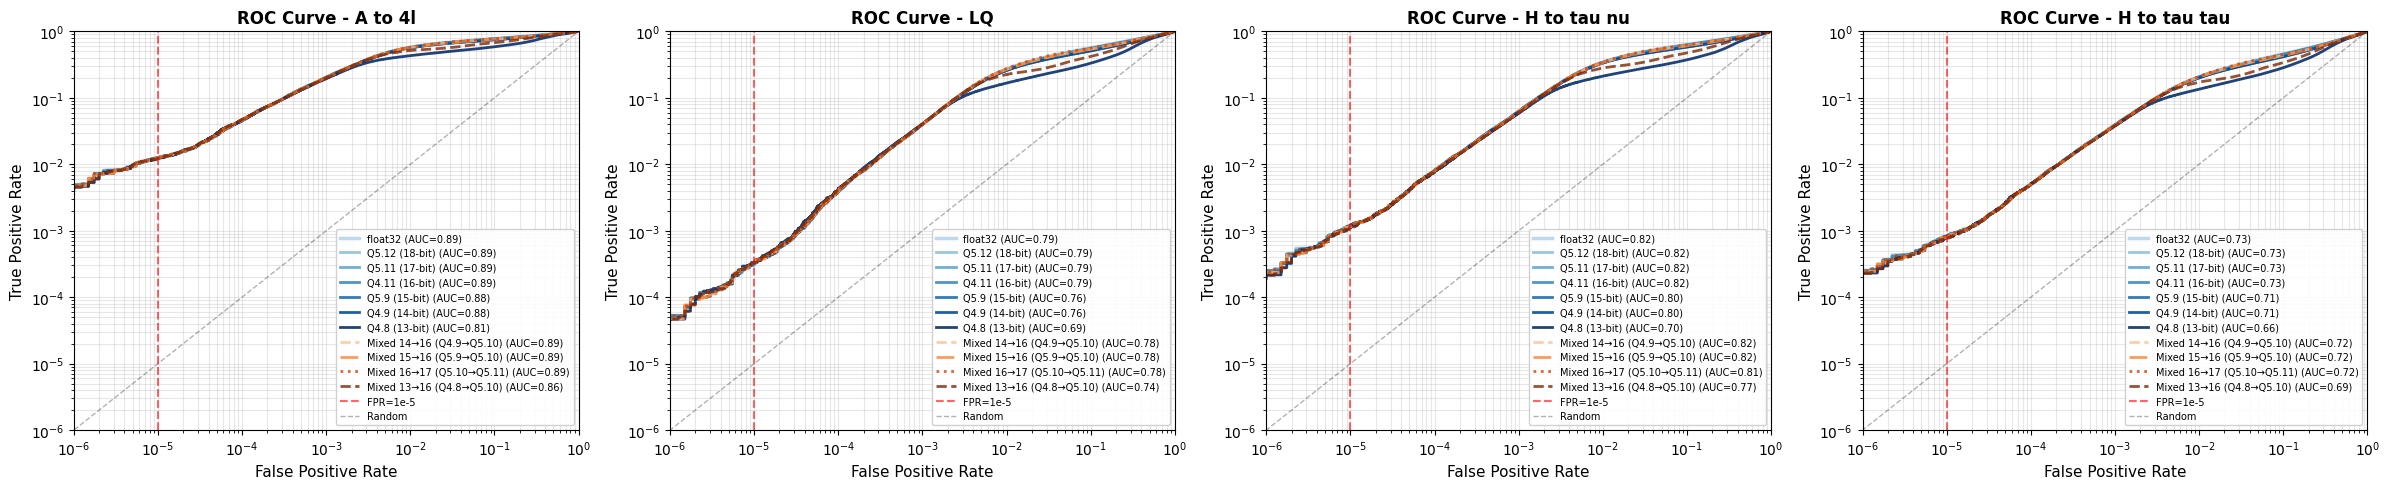

In [49]:
# Plot ROC curves for each signal - combining uniform and mixed precision
fig, axes = plt.subplots(1, n_signals, figsize=(6*n_signals, 5))
if n_signals == 1:
    axes = [axes]

# Define colors and linestyles
uniform_colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(all_scores)))
mixed_colors = plt.cm.Oranges(np.linspace(0.3, 1.0, len(mixed_scores)))
linestyles_uniform = ['-', '-', '-', '-', '-', '-', '-']  # Solid for uniform
linestyles_mixed = ['--', '-.', ':', '--', '-.']  # Varied for mixed

for sig_idx, signal_name in enumerate(signal_loaders.keys()):
    ax = axes[sig_idx]
    
    # Plot uniform precision configs
    for config_idx, (config_name, results) in enumerate(all_scores.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, 
                label=f'{config_name} (AUC={auc_val:.2f})',
                linewidth=2.5 if config_name == 'float32' else 2,
                color=uniform_colors[config_idx],
                linestyle=linestyles_uniform[config_idx],
                alpha=0.9)
    
    # Plot mixed precision configs
    for config_idx, (config_name, results) in enumerate(mixed_scores.items()):
        bkg = results['background']
        sig = results['signals'][signal_name]
        
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        auc_val = auc(fpr, tpr)
        
        # Add layer info to label
        if config_name in mixed_results and 'configs' in mixed_results[config_name]:
            layer_info = "→".join([str(c) for c in mixed_results[config_name]['configs']])
            label_text = f'Mixed {config_name} ({layer_info}) (AUC={auc_val:.2f})'
        else:
            label_text = f'Mixed {config_name} (AUC={auc_val:.2f})'
        
        ax.plot(fpr, tpr, 
                label=label_text,
                linewidth=2,
                color=mixed_colors[config_idx],
                linestyle=linestyles_mixed[config_idx],
                alpha=0.8)
    
    # Add FPR = 1e-5 line
    ax.axvline(x=1e-5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='FPR=1e-5')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Random')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve - {signal_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, framealpha=0.9)
    ax.grid(alpha=0.3, which='both')
    ax.set_xlim([1e-6, 1])
    ax.set_ylim([1e-6, 1])

plt.tight_layout()
plt.savefig(output_dir+"/roc_curves_unified.png", dpi=200)
plt.show()

## 13. Summary: AUC vs Bit-Width

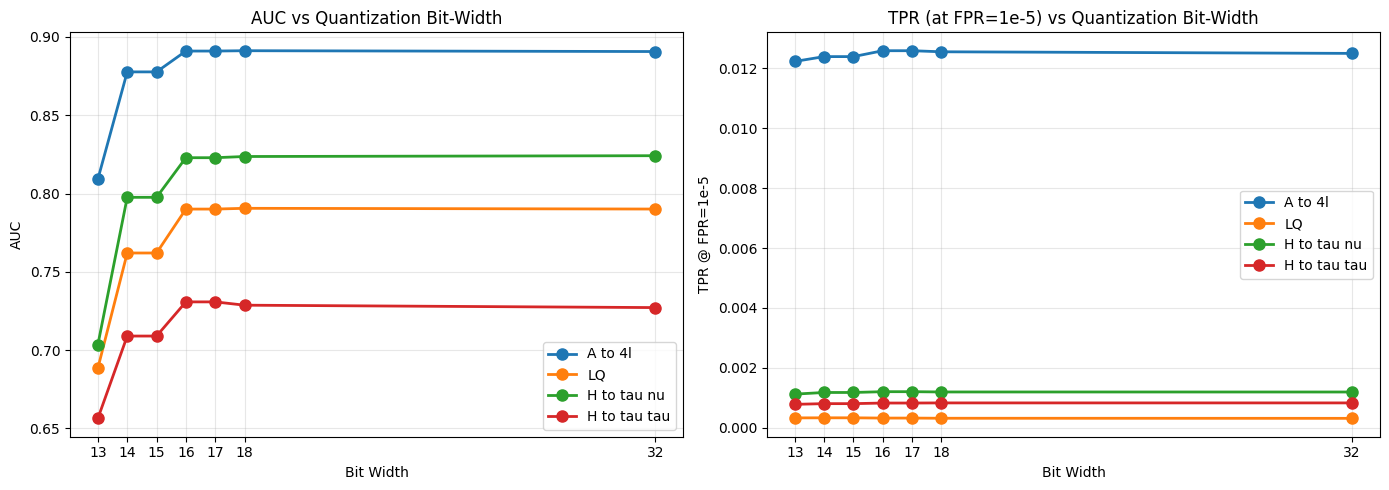

In [50]:
# Extract bit-widths for plotting
bit_widths = [32]  # float32
for n_word, n_frac, name in quantization_configs:
    bit_widths.append(n_word)

# Plot AUC vs bit-width for each signal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUC plot
for signal_name in signal_loaders.keys():
    aucs = []
    for config_name in all_scores.keys():
        bkg = all_scores[config_name]['background']
        sig = all_scores[config_name]['signals'][signal_name]
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        aucs.append(auc(fpr, tpr))
    
    ax1.plot(bit_widths, aucs, marker='o', linewidth=2, markersize=8, label=signal_name)

ax1.set_xlabel('Bit Width')
ax1.set_ylabel('AUC')
ax1.set_title('AUC vs Quantization Bit-Width')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(bit_widths)

# TPR@1e-5 plot
for signal_name in signal_loaders.keys():
    tprs = []
    for config_name in all_scores.keys():
        bkg = all_scores[config_name]['background']
        sig = all_scores[config_name]['signals'][signal_name]
        fpr, tpr = get_roc_curve_data(bkg, sig, anomaly_det=True)
        tprs.append(get_tpr_at_fpr(fpr, tpr, target_fpr=1e-5))
    
    ax2.plot(bit_widths, tprs, marker='o', linewidth=2, markersize=8, label=signal_name)

ax2.set_xlabel('Bit Width')
ax2.set_ylabel('TPR @ FPR=1e-5')
ax2.set_title('TPR (at FPR=1e-5) vs Quantization Bit-Width')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(bit_widths)

plt.tight_layout()
plt.savefig(output_dir+"/auc_vs_quantization.png")
plt.show()

## 14. Save Results

In [51]:
# Save metrics table
df_metrics.to_csv(os.path.join(output_dir, 'quantization_metrics.csv'), index=False)
df_auc_deg.to_csv(os.path.join(output_dir, 'auc_degradation.csv'))
df_tpr_deg.to_csv(os.path.join(output_dir, 'tpr_degradation.csv'))

df_mixed_metrics.to_csv(os.path.join(output_dir, 'quantization_metrics_mixed.csv'), index=False)
df_mixed_auc.to_csv(os.path.join(output_dir, 'auc_degradation_mixed.csv'))
df_mixed_tpr.to_csv(os.path.join(output_dir, 'tpr_degradation_mixed.csv'))
print(f"✅ Results saved to {output_dir}")

✅ Results saved to ../output/Huber_AE_Results_bd8_3//quantization_results
